<a href="https://colab.research.google.com/github/Mizuko821/master_thesis/blob/main/%E5%AE%9F%E9%A8%933_%E3%82%B7%E3%83%B3%E3%82%B0%E3%83%AB%E3%82%BF%E3%82%B9%E3%82%AF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##環境
Google Colabratory  
ランタイム:GPU（V100）を使用

In [ ]:
!pip install transformers torch
!pip install accelerate -U
!pip install fugashi ipadic

In [ ]:
import os
import json
import re
import pandas as pd
from transformers import AutoTokenizer, BertTokenizer, BertPreTrainedModel, BertModel, AdamW, get_linear_schedule_with_warmup, TrainingArguments
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader, TensorDataset, random_split, RandomSampler, SequentialSampler
from torch.optim import AdamW
import matplotlib.pyplot as plt
from torch import nn
from transformers.modeling_outputs import SequenceClassifierOutput
from sklearn.manifold import TSNE
import numpy as np
from typing import Tuple
from sklearn.metrics import confusion_matrix
import seaborn as sns
import random
from sklearn.metrics import f1_score, classification_report

In [ ]:
# デバイスの設定
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [ ]:
def set_seed(seed_value):
    """Set seed for reproducibility.
    """
    random.seed(seed_value)
    np.random.seed(seed_value)
    torch.manual_seed(seed_value)
    torch.cuda.manual_seed_all(seed_value)

set_seed(42)

In [ ]:
#Twitterデータセットへのファイルのパスを設定する
tweet_path = "パスを入力する"

In [ ]:
# CSVファイルを読み込む
df = pd.read_csv(tweet_path)
df.head()

,target,sentence,polarity
0,インボイス制度,フリーランスや、フリーランスへの親近感が強い方が多めのタイムライン構成なので、インボイス制度...,positive
1,インボイス制度,個人的な意見だが徴税制度がすべて悪とは思ってない。インボイス制度はわけのわからん軽減率より分...,positive
2,インボイス制度,こんな状況にもかかわらずインボイス制度賛成というのは理解が難しいです。大企業ではなく、個人事...,negative
3,インボイス制度,インボイス制度はそもそも反対なのだが、まず前提として、あらゆる手続きの負荷は簡便であることを...,negative
4,インボイス制度,インボイス制度何が何でも反対！の人が多いけど消費税払ってるちっさい会社の立場としてはなんでそ...,positive


In [ ]:
# 改行コードを削除
df['sentence'] = df['sentence'].apply(lambda x: re.sub(r'\r?\n', '', x))
df['sentence']

0      フリーランスや、フリーランスへの親近感が強い方が多めのタイムライン構成なので、インボイス制度...
1      個人的な意見だが徴税制度がすべて悪とは思ってない。インボイス制度はわけのわからん軽減率より分...
2      こんな状況にもかかわらずインボイス制度賛成というのは理解が難しいです。大企業ではなく、個人事...
3      インボイス制度はそもそも反対なのだが、まず前提として、あらゆる手続きの負荷は簡便であることを...
4      インボイス制度何が何でも反対！の人が多いけど消費税払ってるちっさい会社の立場としてはなんでそ...
                             ...                        
140    選択的夫婦別姓のメリットは・姓を理由として結婚しなかった人たちが結婚に踏み切れる・親子での姓...
141    そもそも「選択的夫婦別姓が“ないから”結婚できない夫婦」はいても、「選択的夫婦別姓“あるから...
142    選択的夫婦別姓ってノーリスクでリターンしかないと思ってたけど、別姓にしなかった場合に「同姓に...
143    選択的夫婦別姓の問題点について考えてみたが、戸籍とかその辺の法律改正含むし、大混乱になる可能...
144    「選択的夫婦別姓」を私が素直に賛成できないのは、それで生まれた子ども自身が「選択するわけでは...
Name: sentence, Length: 145, dtype: object

In [ ]:
# 極性ラベルを数字にマッピング
label_mapping = {"positive": 0, "neutral": 1, "negative": 2}
df["pol_labels"] = df["polarity"].map(label_mapping)

In [ ]:
num_pol_labels = 3
print(num_pol_labels)

3


### モデル定義

In [ ]:
class SingleTaskModel(BertPreTrainedModel):
    def __init__(self, config):
        super().__init__(config)
        self.num_labels = config.num_labels
        self.config = config

        self.bert = BertModel(config)

        classifier_dropout = (
            config.classifier_dropout if config.classifier_dropout is not None \
                else config.hidden_dropout_prob
        )

        # 極性分類用のネットワーク
        self.pol_dropout = nn.Dropout(classifier_dropout)
        self.pol_layer1 = nn.Linear(config.hidden_size, config.hidden_size)
        self.pol_activation1 = nn.ReLU()
        self.pol_layer2 = nn.Linear(config.hidden_size, config.hidden_size)
        self.pol_activation2 = nn.ReLU()
        self.pol_classifier = nn.Linear(config.hidden_size, config.num_labels)

        self.post_init()

    def forward(self, input_ids=None, attention_mask=None, token_type_ids=None, pol_labels=None, **kwargs):
        outputs = self.bert(input_ids, attention_mask=attention_mask, token_type_ids=token_type_ids, **kwargs)
        pooled_output = outputs[1]
        pooled_output = self.pol_dropout(pooled_output)

        # 感情分類のロジット
        pol_out = self.pol_activation1(self.pol_layer1(pooled_output))
        pol_out = self.pol_activation2(self.pol_layer2(pol_out))
        pol_logits = self.pol_classifier(pol_out)

        return {
            "pol_logits": pol_logits,
            "hidden_states": outputs.hidden_states,
            "attentions": outputs.attentions,
            "pooler_output":outputs.pooler_output
        }

In [ ]:
# 1. モデルアーキテクチャの初期化
#tokenizerとmodelのインスタンス化
modelName = 'cl-tohoku/bert-base-japanese-whole-word-masking'
tokenizer =  AutoTokenizer.from_pretrained(modelName)
model = SingleTaskModel.from_pretrained(modelName, num_labels=num_pol_labels).to(device)

tokenizer_config.json:   0%|          | 0.00/110 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/479 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/258k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/445M [00:00<?, ?B/s]

Some weights of SingleTaskModel were not initialized from the model checkpoint at cl-tohoku/bert-base-japanese-whole-word-masking and are newly initialized: ['pol_classifier.weight', 'pol_layer1.bias', 'pol_layer2.bias', 'pol_layer2.weight', 'pol_classifier.bias', 'pol_layer1.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
#保存された状態辞書のロード
model_path = "実験1で学習したsingleモデルへのパスを入力する"
model.load_state_dict(torch.load(model_path))

<All keys matched successfully>

In [ ]:
# モデルのコピーを複数作成
models = [copy.deepcopy(model) for _ in range(6)]
model1, model2, model3, model4, model5, model6 = models

###モデル実装（クロスバリデーション）


In [ ]:
class TextDataset(Dataset):
    def __init__(self, target, sentence, pol_labels):
        self.target = target.values
        self.sentence = sentence.values
        self.pol_labels = pol_labels.values

    def __len__(self):
        return len(self.target)

    def __getitem__(self, idx):
        return self.target[idx], self.sentence[idx], torch.tensor(self.pol_labels[idx], dtype=torch.long)

In [ ]:
# ターゲットリストの定義（リスト内の要素間にカンマが足りないのを修正）
targets = ['インボイス制度', 'テレワーク', 'ベーシックインカム', 'マイナンバーカード', 'ライドシェア', '選択的夫婦別姓']

# データフレームを分割する関数を定義
def split_df(df, train_targets, val_target, test_target):
    train_df = df[df["target"].isin(train_targets)]
    val_df = df[df["target"] == val_target]
    test_df = df[df["target"] == test_target]
    return train_df, val_df, test_df

# 各分割パターンに対するデータセットを作成
dataloader = {}

# DataLoaderのパラメータ設定
batch_size = 8

In [ ]:
# 各分割パターンに対するデータセットを作成
dfset = {}
dataloader = {}

In [ ]:
for i in range(len(targets)):
    # 分割するターゲットを選択
    train_targets = targets[i:] + targets[:i]
    val_target = train_targets[-2]
    test_target = train_targets[-1]

    # データセットを分割
    train_df, val_df, test_df = split_df(df, train_targets[:-2], val_target, test_target)

    # 分割したデータセットを辞書に保存
    dfset[f'train_df{i+1}'] = train_df
    dfset[f'val_df{i+1}'] = val_df
    dfset[f'test_df{i+1}'] = test_df

    train_dataset = TextDataset(pd.Series(train_df["target"]), pd.Series(train_df["sentence"]), pd.Series(train_df["pol_labels"]))
    val_dataset = TextDataset(pd.Series(val_df["target"]), pd.Series(val_df["sentence"]), pd.Series(val_df["pol_labels"]))
    test_dataset = TextDataset(pd.Series(test_df["target"]), pd.Series(test_df["sentence"]), pd.Series(test_df["pol_labels"]))

    # テスト用データローダー
    train_tweetloader = DataLoader(train_dataset, batch_size=batch_size)
    val_tweetloader = DataLoader(val_dataset, batch_size=batch_size)
    test_tweetloader = DataLoader(test_dataset, batch_size=batch_size)

    # 分割したデータセットを辞書に保存
    dataloader[f'train_tweetloader{i+1}'] = train_tweetloader
    dataloader[f'val_tweetloader{i+1}'] = val_tweetloader
    dataloader[f'test_tweetloader{i+1}'] = test_tweetloader

### 途中経過を表示する

In [ ]:
# テスト用の関数before
def modeltest(model, dataloader):
  model.eval()
  total = len(dataloader.dataset)
  len_dataloder = len(dataloader)
  pol_correct = 0
  total_loss = 0 #追加
  with torch.no_grad():
    for target, sentence, pol_labels in dataloader:
      pol_labels = pol_labels.to(device)
      input = tokenizer(target, sentence, padding=True, truncation=True, return_tensors='pt').to(device)
      pred = model(**input)

      pred_pol_labels = pred["pol_logits"].argmax(dim=1)
      pol_correct += (pred_pol_labels == pol_labels).sum().item()

      pol_loss = loss_fct(pred["pol_logits"], pol_labels)
      loss = pol_loss
      total_loss += loss.item()

      # F1スコアの計算
      pol_f1 = f1_score(pol_labels.cpu(), pred_pol_labels.cpu(), average='macro')

  return pol_correct/total, total_loss/len_dataloder, pol_f1

In [ ]:
# 途中経過の表示
def reportProgress(model, dataloader, pol_labels):
  model.eval()
  pol_acc, val_loss, pol_f1= modeltest(model, dataloader)
  val_losslist.append(val_loss)
  pol_acclist.append(pol_acc)
  pol_f1list.append(pol_f1)
  print("epoch[%d/%d] trainLoss=%f, validLoss=%f, pol_acc=%.2f%%, pol_f1=%.4f" % (epoch+1, num_epoch, train_loss/iter, val_loss, pol_acc*100, pol_f1))
  model.train()

###モデル実行

In [ ]:
# 学習用の設定
num_epoch = 10 #デフォルトのepoch数
loss_fct = nn.CrossEntropyLoss()
criterion = nn.CrossEntropyLoss() # 損失関数はクロスエントロピー
train_losslist = []
val_losslist = []
pol_acclist = []
category_acclist = []
pol_f1list = []
category_f1list = []

accuracy_set = []
f1_set = []

# 誤った予測とその詳細を記録するリスト
incorrect_polarity_samples = []

#### クロスバリデーション1

In [ ]:
#モデルの重みを保存するフォルダを設定する
model_save = "保存先のファイルへのパスを設定する"

In [ ]:
#学習1回目
model1.train()
optimizer = torch.optim.RMSprop(model1.parameters(), lr=1e-5) # RMSpropを使う

for epoch in range(num_epoch):  # num_epoch分繰り返す
    train_loss = 0
    for iter, (target, sentence, pol_labels) in enumerate(dataloader["train_tweetloader1"], 1):
        pol_labels = pol_labels.to(device)
        input = tokenizer(target, sentence, padding=True, truncation=True, return_tensors='pt').to(device)
        optimizer.zero_grad()
        pred = model1(**input)
        pol_loss = loss_fct(pred["pol_logits"], pol_labels)
        loss = pol_loss
        train_loss += loss.item()
        loss.backward()  # 誤差伝播
        optimizer.step()  # パラメータ更新

    # epochの最後
    reportProgress(model1, dataloader["val_tweetloader1"], pol_labels)
    torch.save(model1.state_dict(), model_save+f"model_epoch_{epoch+1}.pth")

epoch[1/10] trainLoss=1.733117, validLoss=1.013942, pol_acc=45.83%, pol_f1=0.4222
epoch[2/10] trainLoss=0.663017, validLoss=0.924349, pol_acc=50.00%, pol_f1=0.5556
epoch[3/10] trainLoss=0.367665, validLoss=0.949285, pol_acc=54.17%, pol_f1=0.5556
epoch[4/10] trainLoss=0.165252, validLoss=0.844235, pol_acc=54.17%, pol_f1=0.5556
epoch[5/10] trainLoss=0.070389, validLoss=0.873723, pol_acc=54.17%, pol_f1=0.5556
epoch[6/10] trainLoss=0.062125, validLoss=0.976474, pol_acc=54.17%, pol_f1=0.5556
epoch[7/10] trainLoss=0.022317, validLoss=0.958441, pol_acc=54.17%, pol_f1=0.5556
epoch[8/10] trainLoss=0.021145, validLoss=0.889389, pol_acc=58.33%, pol_f1=0.5556
epoch[9/10] trainLoss=0.013424, validLoss=0.932039, pol_acc=58.33%, pol_f1=0.5556
epoch[10/10] trainLoss=0.007711, validLoss=0.930426, pol_acc=58.33%, pol_f1=0.5556


In [ ]:
#保存された状態辞書のロード
model_path = "採用するモデルの重みへのパスを入力"
model1.load_state_dict(torch.load(model_path))

<All keys matched successfully>

In [ ]:
#テストデータでの検証

model1.eval()  # モデルを評価モードに変更
total_loss, pol_total_correct, total_samples = 0, 0, len(test_dataset)
pol_predictions, pol_labels_list = [], []
pol_predictions_common, pol_labels_list_common = [], []

with torch.no_grad():  # 評価中に勾配の計算は不要
    for i, (target, sentence, pol_labels) in enumerate(dataloader["test_tweetloader1"]):
        pol_labels = pol_labels.to(device)
        input = tokenizer(target, sentence, padding=True, truncation=True, return_tensors='pt').to(device)
        pred = model1(**input)
        pol_loss = loss_fct(pred["pol_logits"], pol_labels)
        loss = pol_loss
        total_loss += loss.item()

        # 精度計算
        pred_pol_labels = pred["pol_logits"].argmax(dim=1)
        pol_total_correct += (pred_pol_labels == pol_labels).sum().item()

        # 予測とラベルをリストに追加
        pol_predictions.extend(pred_pol_labels.cpu().numpy())
        pol_labels_list.extend(pol_labels.cpu().numpy())

        # 予測とラベルをコモンリストに追加
        pol_predictions_common.extend(pred_pol_labels.cpu().numpy())
        pol_labels_list_common.extend(pol_labels.cpu().numpy())

        # 予測が誤っていたサンプルのインデックスを記録
        incorrect_pol = (pred_pol_labels != pol_labels).nonzero(as_tuple=True)[0]

        for idx in incorrect_pol:
            incorrect_polarity_samples.append({
                'batch_index': i,
                'sample_index': idx.item(),
                'target': target[idx],  # .item() は適宜変更
                'sentence': sentence[idx],  # 適宜変更
                'predicted_label': pred_pol_labels[idx].item(),
                'correct_label': pol_labels[idx].item()
            })

avg_loss = total_loss / len(dataloader["test_tweetloader1"])
pol_accuracy = pol_total_correct / total_samples
# F1スコアの計算
pol_f1 = f1_score(pol_labels_list, pol_predictions, average='macro')
# 分類レポート
pol_report = classification_report(pol_labels_list, pol_predictions)

accuracy_set.append(pol_accuracy)
f1_set.append(pol_f1)

# 結果の出力
print(f"Test Loss: {avg_loss:.4f}")
print(f"Test Pol Accuracy: {pol_accuracy:.4f}, F1: {pol_f1:.4f}")
print("Pol Classification Report:\n", pol_report)

Test Loss: 1.0296
Test Pol Accuracy: 0.5833, F1: 0.5564
Pol Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.67      0.71         9
           1       0.33      0.43      0.38         7
           2       0.62      0.56      0.59         9

    accuracy                           0.56        25
   macro avg       0.57      0.55      0.56        25
weighted avg       0.59      0.56      0.57        25



#### クロスバリデーション2

In [ ]:
num_epoch = "採用するepoch数を入力"

In [ ]:
chack_model = model2
train_tweetloader = dataloader["train_tweetloader2"]
val_tweetloader = dataloader["val_tweetloader2"]
test_tweetloader = dataloader["test_tweetloader2"]

In [ ]:
#学習本体
chack_model.train()
optimizer = torch.optim.RMSprop(chack_model.parameters(), lr=1e-5) # RMSpropを使う

for epoch in range(num_epoch):  # num_epoch分繰り返す
    train_loss = 0
    for iter, (target, sentence, pol_labels) in enumerate(train_tweetloader, 1):
        pol_labels = pol_labels.to(device)
        input = tokenizer(target, sentence, padding=True, truncation=True, return_tensors='pt').to(device)
        optimizer.zero_grad()
        pred = chack_model(**input)
        pol_loss = loss_fct(pred["pol_logits"], pol_labels)
        loss = pol_loss
        train_loss += loss.item()
        loss.backward()  # 誤差伝播
        optimizer.step()  # パラメータ更新

    # epochの最後
    reportProgress(chack_model, val_tweetloader, pol_labels)

epoch[1/3] trainLoss=1.634800, validLoss=0.912824, pol_acc=44.00%, pol_f1=1.0000
epoch[2/3] trainLoss=0.573707, validLoss=1.105571, pol_acc=52.00%, pol_f1=1.0000
epoch[3/3] trainLoss=0.333455, validLoss=1.247309, pol_acc=44.00%, pol_f1=1.0000


In [ ]:
#テストデータでの検証

chack_model.eval()  # モデルを評価モードに変更
total_loss, pol_total_correct, total_samples = 0, 0, len(test_dataset)
pol_predictions, pol_labels_list = [], []

with torch.no_grad():  # 評価中に勾配の計算は不要
    for i, (target, sentence, pol_labels) in enumerate(test_tweetloader):
        pol_labels = pol_labels.to(device)
        input = tokenizer(target, sentence, padding=True, truncation=True, return_tensors='pt').to(device)
        pred = chack_model(**input)
        pol_loss = loss_fct(pred["pol_logits"], pol_labels)
        loss = pol_loss
        total_loss += loss.item()

        # 精度計算
        pred_pol_labels = pred["pol_logits"].argmax(dim=1)
        pol_total_correct += (pred_pol_labels == pol_labels).sum().item()

        # 予測とラベルをリストに追加
        pol_predictions.extend(pred_pol_labels.cpu().numpy())
        pol_labels_list.extend(pol_labels.cpu().numpy())

        # 予測とラベルをコモンリストに追加
        pol_predictions_common.extend(pred_pol_labels.cpu().numpy())
        pol_labels_list_common.extend(pol_labels.cpu().numpy())

        # 予測が誤っていたサンプルのインデックスを記録
        incorrect_pol = (pred_pol_labels != pol_labels).nonzero(as_tuple=True)[0]

        for idx in incorrect_pol:
            incorrect_polarity_samples.append({
                'batch_index': i,
                'sample_index': idx.item(),
                'target': target[idx],  # .item() は適宜変更
                'sentence': sentence[idx],  # 適宜変更
                'predicted_label': pred_pol_labels[idx].item(),
                'correct_label': pol_labels[idx].item()
            })

avg_loss = total_loss / len(test_tweetloader)
pol_accuracy = pol_total_correct / total_samples
# F1スコアの計算
pol_f1 = f1_score(pol_labels_list, pol_predictions, average='macro')
# 分類レポート
pol_report = classification_report(pol_labels_list, pol_predictions)

accuracy_set.append(pol_accuracy)
f1_set.append(pol_f1)

# 結果の出力
print(f"Test Loss: {avg_loss:.4f}")
print(f"Test Pol Accuracy: {pol_accuracy:.4f}, F1: {pol_f1:.4f}")
print("Pol Classification Report:\n", pol_report)

Test Loss: 1.0732
Test Pol Accuracy: 0.5417, F1: 0.5425
Pol Classification Report:
               precision    recall  f1-score   support

           0       0.70      1.00      0.82         7
           1       0.50      0.25      0.33         8
           2       0.44      0.50      0.47         8

    accuracy                           0.57        23
   macro avg       0.55      0.58      0.54        23
weighted avg       0.54      0.57      0.53        23



#### クロスバリデーション3

In [ ]:
chack_model = model3
train_tweetloader = dataloader["train_tweetloader3"]
val_tweetloader = dataloader["val_tweetloader3"]
test_tweetloader = dataloader["test_tweetloader3"]

In [ ]:
#学習本体
chack_model.train()
optimizer = torch.optim.RMSprop(chack_model.parameters(), lr=1e-5) # RMSpropを使う

for epoch in range(num_epoch):  # num_epoch分繰り返す
    train_loss = 0
    for iter, (target, sentence, pol_labels) in enumerate(train_tweetloader, 1):
        pol_labels = pol_labels.to(device)
        input = tokenizer(target, sentence, padding=True, truncation=True, return_tensors='pt').to(device)
        optimizer.zero_grad()
        pred = chack_model(**input)
        pol_loss = loss_fct(pred["pol_logits"], pol_labels)
        loss = pol_loss
        train_loss += loss.item()
        loss.backward()  # 誤差伝播
        optimizer.step()  # パラメータ更新

    # epochの最後
    reportProgress(chack_model, val_tweetloader, pol_labels)

epoch[1/3] trainLoss=1.709421, validLoss=1.488973, pol_acc=52.17%, pol_f1=0.4571
epoch[2/3] trainLoss=0.605366, validLoss=0.936288, pol_acc=60.87%, pol_f1=0.8222
epoch[3/3] trainLoss=0.332061, validLoss=0.970010, pol_acc=56.52%, pol_f1=0.8222


In [ ]:
#テストデータでの検証

chack_model.eval()  # モデルを評価モードに変更
total_loss, pol_total_correct, total_samples = 0, 0, len(test_dataset)
pol_predictions, pol_labels_list = [], []

with torch.no_grad():  # 評価中に勾配の計算は不要
    for i, (target, sentence, pol_labels) in enumerate(test_tweetloader):
        pol_labels = pol_labels.to(device)
        input = tokenizer(target, sentence, padding=True, truncation=True, return_tensors='pt').to(device)
        pred = chack_model(**input)
        pol_loss = loss_fct(pred["pol_logits"], pol_labels)
        loss = pol_loss
        total_loss += loss.item()

        # 精度計算
        pred_pol_labels = pred["pol_logits"].argmax(dim=1)
        pol_total_correct += (pred_pol_labels == pol_labels).sum().item()

        # 予測とラベルをリストに追加
        pol_predictions.extend(pred_pol_labels.cpu().numpy())
        pol_labels_list.extend(pol_labels.cpu().numpy())

        # 予測とラベルをコモンリストに追加
        pol_predictions_common.extend(pred_pol_labels.cpu().numpy())
        pol_labels_list_common.extend(pol_labels.cpu().numpy())

        # 予測が誤っていたサンプルのインデックスを記録
        incorrect_pol = (pred_pol_labels != pol_labels).nonzero(as_tuple=True)[0]

        for idx in incorrect_pol:
            incorrect_polarity_samples.append({
                'batch_index': i,
                'sample_index': idx.item(),
                'target': target[idx],  # .item() は適宜変更
                'sentence': sentence[idx],  # 適宜変更
                'predicted_label': pred_pol_labels[idx].item(),
                'correct_label': pol_labels[idx].item()
            })

avg_loss = total_loss / len(test_tweetloader)
pol_accuracy = pol_total_correct / total_samples
# F1スコアの計算
pol_f1 = f1_score(pol_labels_list, pol_predictions, average='macro')
# 分類レポート
pol_report = classification_report(pol_labels_list, pol_predictions)

accuracy_set.append(pol_accuracy)
f1_set.append(pol_f1)

# 結果の出力
print(f"Test Loss: {avg_loss:.4f}")
print(f"Test Pol Accuracy: {pol_accuracy:.4f}, F1: {pol_f1:.4f}")
print("Pol Classification Report:\n", pol_report)

Test Loss: 1.0666
Test Pol Accuracy: 0.6250, F1: 0.5924
Pol Classification Report:
               precision    recall  f1-score   support

           0       0.55      0.60      0.57        10
           1       0.50      0.50      0.50         6
           2       0.75      0.67      0.71         9

    accuracy                           0.60        25
   macro avg       0.60      0.59      0.59        25
weighted avg       0.61      0.60      0.60        25



#### クロスバリデーション4

In [ ]:
chack_model = model4
train_tweetloader = dataloader["train_tweetloader4"]
val_tweetloader = dataloader["val_tweetloader4"]
test_tweetloader = dataloader["test_tweetloader4"]

In [ ]:
#学習本体
chack_model.train()
optimizer = torch.optim.RMSprop(chack_model.parameters(), lr=1e-5) # RMSpropを使う

for epoch in range(num_epoch):  # num_epoch分繰り返す
    train_loss = 0
    for iter, (target, sentence, pol_labels) in enumerate(train_tweetloader, 1):
        pol_labels = pol_labels.to(device)
        input = tokenizer(target, sentence, padding=True, truncation=True, return_tensors='pt').to(device)
        optimizer.zero_grad()
        pred = chack_model(**input)
        pol_loss = loss_fct(pred["pol_logits"], pol_labels)
        loss = pol_loss
        train_loss += loss.item()
        loss.backward()  # 誤差伝播
        optimizer.step()  # パラメータ更新

    # epochの最後
    reportProgress(chack_model, val_tweetloader, pol_labels)

epoch[1/3] trainLoss=1.870319, validLoss=1.185977, pol_acc=36.00%, pol_f1=1.0000
epoch[2/3] trainLoss=0.735131, validLoss=1.060876, pol_acc=40.00%, pol_f1=1.0000
epoch[3/3] trainLoss=0.355140, validLoss=1.119426, pol_acc=48.00%, pol_f1=1.0000


In [ ]:
#テストデータでの検証

chack_model.eval()  # モデルを評価モードに変更
total_loss, pol_total_correct, total_samples = 0, 0, len(test_dataset)
pol_predictions, pol_labels_list = [], []

with torch.no_grad():  # 評価中に勾配の計算は不要
    for i, (target, sentence, pol_labels) in enumerate(test_tweetloader):
        pol_labels = pol_labels.to(device)
        input = tokenizer(target, sentence, padding=True, truncation=True, return_tensors='pt').to(device)
        pred = chack_model(**input)
        pol_loss = loss_fct(pred["pol_logits"], pol_labels)
        loss = pol_loss
        total_loss += loss.item()

        # 精度計算
        pred_pol_labels = pred["pol_logits"].argmax(dim=1)
        pol_total_correct += (pred_pol_labels == pol_labels).sum().item()

        # 予測とラベルをリストに追加
        pol_predictions.extend(pred_pol_labels.cpu().numpy())
        pol_labels_list.extend(pol_labels.cpu().numpy())

        # 予測とラベルをコモンリストに追加
        pol_predictions_common.extend(pred_pol_labels.cpu().numpy())
        pol_labels_list_common.extend(pol_labels.cpu().numpy())

        # 予測が誤っていたサンプルのインデックスを記録
        incorrect_pol = (pred_pol_labels != pol_labels).nonzero(as_tuple=True)[0]

        for idx in incorrect_pol:
            incorrect_polarity_samples.append({
                'batch_index': i,
                'sample_index': idx.item(),
                'target': target[idx],  # .item() は適宜変更
                'sentence': sentence[idx],  # 適宜変更
                'predicted_label': pred_pol_labels[idx].item(),
                'correct_label': pol_labels[idx].item()
            })

avg_loss = total_loss / len(test_tweetloader)
pol_accuracy = pol_total_correct / total_samples
# F1スコアの計算
pol_f1 = f1_score(pol_labels_list, pol_predictions, average='macro')
# 分類レポート
pol_report = classification_report(pol_labels_list, pol_predictions)

accuracy_set.append(pol_accuracy)
f1_set.append(pol_f1)

# 結果の出力
print(f"Test Loss: {avg_loss:.4f}")
print(f"Test Pol Accuracy: {pol_accuracy:.4f}, F1: {pol_f1:.4f}")
print("Pol Classification Report:\n", pol_report)

Test Loss: 0.7610
Test Pol Accuracy: 0.7083, F1: 0.6714
Pol Classification Report:
               precision    recall  f1-score   support

           0       0.67      0.75      0.71         8
           1       0.67      0.50      0.57         8
           2       0.70      0.78      0.74         9

    accuracy                           0.68        25
   macro avg       0.68      0.68      0.67        25
weighted avg       0.68      0.68      0.67        25



#### クロスバリデーション5

In [ ]:
chack_model = model5
train_tweetloader = dataloader["train_tweetloader5"]
val_tweetloader = dataloader["val_tweetloader5"]
test_tweetloader = dataloader["test_tweetloader5"]

In [ ]:
#学習本体
chack_model.train()
optimizer = torch.optim.RMSprop(chack_model.parameters(), lr=1e-5) # RMSpropを使う

for epoch in range(num_epoch):  # num_epoch分繰り返す
    train_loss = 0
    for iter, (target, sentence, pol_labels) in enumerate(train_tweetloader, 1):
        pol_labels = pol_labels.to(device)
        input = tokenizer(target, sentence, padding=True, truncation=True, return_tensors='pt').to(device)
        optimizer.zero_grad()
        pred = chack_model(**input)
        pol_loss = loss_fct(pred["pol_logits"], pol_labels)
        loss = pol_loss
        train_loss += loss.item()
        loss.backward()  # 誤差伝播
        optimizer.step()  # パラメータ更新

    # epochの最後
    reportProgress(chack_model, val_tweetloader, pol_labels)

epoch[1/3] trainLoss=1.794743, validLoss=0.788057, pol_acc=64.00%, pol_f1=1.0000
epoch[2/3] trainLoss=0.594949, validLoss=0.631813, pol_acc=60.00%, pol_f1=1.0000
epoch[3/3] trainLoss=0.275805, validLoss=0.588994, pol_acc=60.00%, pol_f1=1.0000


In [ ]:
#テストデータでの検証

chack_model.eval()  # モデルを評価モードに変更
total_loss, pol_total_correct, total_samples = 0, 0, len(test_dataset)
pol_predictions, pol_labels_list = [], []

with torch.no_grad():  # 評価中に勾配の計算は不要
    for i, (target, sentence, pol_labels) in enumerate(test_tweetloader):
        pol_labels = pol_labels.to(device)
        input = tokenizer(target, sentence, padding=True, truncation=True, return_tensors='pt').to(device)
        pred = chack_model(**input)
        pol_loss = loss_fct(pred["pol_logits"], pol_labels)
        loss = pol_loss
        total_loss += loss.item()

        # 精度計算
        pred_pol_labels = pred["pol_logits"].argmax(dim=1)
        pol_total_correct += (pred_pol_labels == pol_labels).sum().item()

        # 予測とラベルをリストに追加
        pol_predictions.extend(pred_pol_labels.cpu().numpy())
        pol_labels_list.extend(pol_labels.cpu().numpy())

        # 予測とラベルをコモンリストに追加
        pol_predictions_common.extend(pred_pol_labels.cpu().numpy())
        pol_labels_list_common.extend(pol_labels.cpu().numpy())

        # 予測が誤っていたサンプルのインデックスを記録
        incorrect_pol = (pred_pol_labels != pol_labels).nonzero(as_tuple=True)[0]

        for idx in incorrect_pol:
            incorrect_polarity_samples.append({
                'batch_index': i,
                'sample_index': idx.item(),
                'target': target[idx],  # .item() は適宜変更
                'sentence': sentence[idx],  # 適宜変更
                'predicted_label': pred_pol_labels[idx].item(),
                'correct_label': pol_labels[idx].item()
            })

avg_loss = total_loss / len(test_tweetloader)
pol_accuracy = pol_total_correct / total_samples
# F1スコアの計算
pol_f1 = f1_score(pol_labels_list, pol_predictions, average='macro')
# 分類レポート
pol_report = classification_report(pol_labels_list, pol_predictions)

accuracy_set.append(pol_accuracy)
f1_set.append(pol_f1)

# 結果の出力
print(f"Test Loss: {avg_loss:.4f}")
print(f"Test Pol Accuracy: {pol_accuracy:.4f}, F1: {pol_f1:.4f}")
print("Pol Classification Report:\n", pol_report)

Test Loss: 1.6939
Test Pol Accuracy: 0.5417, F1: 0.5681
Pol Classification Report:
               precision    recall  f1-score   support

           0       0.56      0.56      0.56         9
           1       0.67      0.44      0.53         9
           2       0.50      0.80      0.62         5

    accuracy                           0.57        23
   macro avg       0.57      0.60      0.57        23
weighted avg       0.59      0.57      0.56        23



#### クロスバリデーション6

In [ ]:
chack_model = model6
train_tweetloader = dataloader["train_tweetloader6"]
val_tweetloader = dataloader["val_tweetloader6"]
test_tweetloader = dataloader["test_tweetloader6"]

In [ ]:
#学習本体
chack_model.train()
optimizer = torch.optim.RMSprop(chack_model.parameters(), lr=1e-5) # RMSpropを使う

for epoch in range(num_epoch):  # num_epoch分繰り返す
    train_loss = 0
    for iter, (target, sentence, pol_labels) in enumerate(train_tweetloader, 1):
        pol_labels = pol_labels.to(device)
        input = tokenizer(target, sentence, padding=True, truncation=True, return_tensors='pt').to(device)
        optimizer.zero_grad()
        pred = chack_model(**input)
        pol_loss = loss_fct(pred["pol_logits"], pol_labels)
        loss = pol_loss
        train_loss += loss.item()
        loss.backward()  # 誤差伝播
        optimizer.step()  # パラメータ更新

    # epochの最後
    reportProgress(chack_model, val_tweetloader, pol_labels)

epoch[1/3] trainLoss=1.633998, validLoss=1.603992, pol_acc=21.74%, pol_f1=0.2000
epoch[2/3] trainLoss=0.725780, validLoss=1.403067, pol_acc=52.17%, pol_f1=0.3556
epoch[3/3] trainLoss=0.330033, validLoss=1.354892, pol_acc=65.22%, pol_f1=0.4444


In [ ]:
#テストデータでの検証

chack_model.eval()  # モデルを評価モードに変更
total_loss, pol_total_correct, total_samples = 0, 0, len(test_dataset)
pol_predictions, pol_labels_list = [], []

with torch.no_grad():  # 評価中に勾配の計算は不要
    for i, (target, sentence, pol_labels) in enumerate(test_tweetloader):
        pol_labels = pol_labels.to(device)
        input = tokenizer(target, sentence, padding=True, truncation=True, return_tensors='pt').to(device)
        pred = chack_model(**input)
        pol_loss = loss_fct(pred["pol_logits"], pol_labels)
        loss = pol_loss
        total_loss += loss.item()

        # 精度計算
        pred_pol_labels = pred["pol_logits"].argmax(dim=1)
        pol_total_correct += (pred_pol_labels == pol_labels).sum().item()

        # 予測とラベルをリストに追加
        pol_predictions.extend(pred_pol_labels.cpu().numpy())
        pol_labels_list.extend(pol_labels.cpu().numpy())

        # 予測とラベルをコモンリストに追加
        pol_predictions_common.extend(pred_pol_labels.cpu().numpy())
        pol_labels_list_common.extend(pol_labels.cpu().numpy())

        # 予測が誤っていたサンプルのインデックスを記録
        incorrect_pol = (pred_pol_labels != pol_labels).nonzero(as_tuple=True)[0]

        for idx in incorrect_pol:
            incorrect_polarity_samples.append({
                'batch_index': i,
                'sample_index': idx.item(),
                'target': target[idx],  # .item() は適宜変更
                'sentence': sentence[idx],  # 適宜変更
                'predicted_label': pred_pol_labels[idx].item(),
                'correct_label': pol_labels[idx].item()
            })

avg_loss = total_loss / len(test_tweetloader)
pol_accuracy = pol_total_correct / total_samples
# F1スコアの計算
pol_f1 = f1_score(pol_labels_list, pol_predictions, average='macro')
# 分類レポート
pol_report = classification_report(pol_labels_list, pol_predictions)

accuracy_set.append(pol_accuracy)
f1_set.append(pol_f1)

# 結果の出力
print(f"Test Loss: {avg_loss:.4f}")
print(f"Test Pol Accuracy: {pol_accuracy:.4f}, F1: {pol_f1:.4f}")
print("Pol Classification Report:\n", pol_report)

Test Loss: 0.8128
Test Pol Accuracy: 0.5833, F1: 0.5278
Pol Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.75      0.75         8
           1       0.50      0.70      0.58        10
           2       0.50      0.17      0.25         6

    accuracy                           0.58        24
   macro avg       0.58      0.54      0.53        24
weighted avg       0.58      0.58      0.56        24



### 結果

In [ ]:
# 結果の出力
print("Test Pol Accuracy:" + str(np.mean(accuracy_set)))
print("Test Pol F1:" + str(np.mean(f1_set)))

Test Pol Accuracy:0.5972222222222222
Test Pol F1:0.5764244121700263


### 不正解の事例

In [ ]:
len(incorrect_polarity_samples)

59

In [ ]:
incorrect_polarity_samples

[{'batch_index': 0,
  'sample_index': 0,
  'target': '選択的夫婦別姓',
  'sentence': '「自分は結婚したら相手と同じ名字にしたい」と「選択的夫婦別姓に賛成」はダブルスタンダードではなくて普通に両立すること  前者は個人の意思で、後者は他人の意思を尊重することだからです選択的夫婦別姓に賛成か反対かは、他人の意思を尊重するか否か',
  'predicted_label': 1,
  'correct_label': 0},
 {'batch_index': 0,
  'sample_index': 1,
  'target': '選択的夫婦別姓',
  'sentence': 'むしろ選択的夫婦別姓に何のメリットがあるんですか？',
  'predicted_label': 1,
  'correct_label': 2},
 {'batch_index': 0,
  'sample_index': 2,
  'target': '選択的夫婦別姓',
  'sentence': '選択的夫婦別姓の反対意見で改姓できる人と結婚すればいいというのを見たけど、改姓できない、したくない人の方が多いよな、現に結婚した男性の95%は改姓していないわけだし、改姓できる男性と結婚できる女性は限りなく少ない',
  'predicted_label': 2,
  'correct_label': 0},
 {'batch_index': 0,
  'sample_index': 5,
  'target': '選択的夫婦別姓',
  'sentence': '選択的夫婦別姓について、今言われている選択的夫婦別姓のメリットは、職場の通称使用選択を可能にすることを義務化すれば、ほぼ解決できるような気がするので、あえて導入する必要があるのだろうかと思う。',
  'predicted_label': 1,
  'correct_label': 2},
 {'batch_index': 1,
  'sample_index': 2,
  'target': '選択的夫婦別姓',
  'sentence': '例えば、「選択的夫婦別姓制」について、ジャーナリズムの役割は、それを推進する立場で報道することではない。反対する立場で

### Confusion Matrix

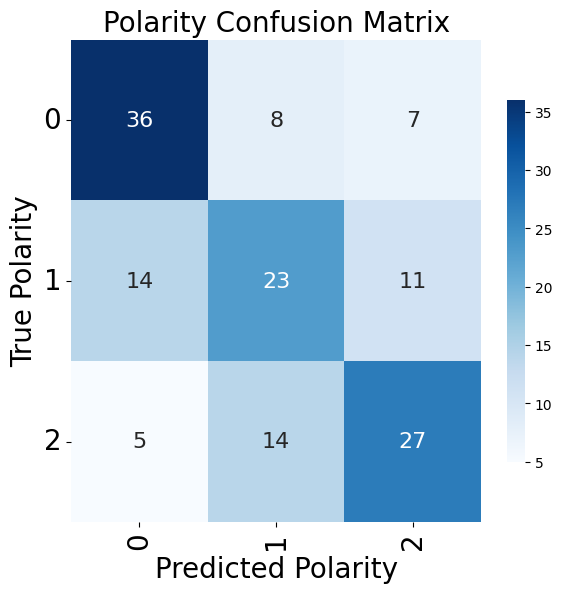

In [ ]:
# Confusion Matrixの計算
polarity_cm = confusion_matrix(pol_labels_list_common, pol_predictions_common)

# Confusion Matrixの計算後...
plt.figure(figsize=(6, 6))  # サイズ調整

sns.heatmap(polarity_cm, annot=True, fmt="", cmap='Blues', cbar_kws={"shrink": 0.75}, annot_kws={"size": 16})
plt.xlabel('Predicted Polarity', fontsize=20)
plt.ylabel('True Polarity', fontsize=20)
plt.title('Polarity Confusion Matrix', fontsize=20)
plt.tight_layout()
plt.xticks(rotation=90, fontsize=20)
plt.yticks(rotation=0, fontsize=20)
plt.show()